In [1]:
from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)

Project root: d:\Personal\MineProjects\PowerBIProjects\Project1\NYC-Taxi-Demand-Revenue-Analytics
Raw data directory: d:\Personal\MineProjects\PowerBIProjects\Project1\NYC-Taxi-Demand-Revenue-Analytics\data\raw


In [2]:
parquet_files = sorted(RAW_DATA_DIR.rglob("*.parquet"))

print(f"Total Parquet files: {len(parquet_files)}")

Total Parquet files: 62


In [3]:
schema_summary = {}

for file in parquet_files:
    parquet = pq.ParquetFile(file)

    relative_path = file.relative_to(RAW_DATA_DIR)
    taxi_type = relative_path.parts[0]
    year = relative_path.parts[1]

    key = f"{taxi_type.upper()} {year}"

    schema_summary[key] = {
        column: str(dtype)
        for column, dtype in zip(
            parquet.schema_arrow.names,
            parquet.schema_arrow.types
        )
    }

for dataset, schema in schema_summary.items():
    print(f"\n{'=' * 70}")
    print(dataset)
    print("=" * 70)

    for column, dtype in schema.items():
        print(f"{column:<30} {dtype}")


GREEN 2024
VendorID                       int32
lpep_pickup_datetime           timestamp[us]
lpep_dropoff_datetime          timestamp[us]
store_and_fwd_flag             large_string
RatecodeID                     int64
PULocationID                   int32
DOLocationID                   int32
passenger_count                int64
trip_distance                  double
fare_amount                    double
extra                          double
mta_tax                        double
tip_amount                     double
tolls_amount                   double
ehail_fee                      double
improvement_surcharge          double
total_amount                   double
payment_type                   int64
trip_type                      int64
congestion_surcharge           double

GREEN 2025
VendorID                       int32
lpep_pickup_datetime           timestamp[us]
lpep_dropoff_datetime          timestamp[us]
store_and_fwd_flag             large_string
RatecodeID                     i

## Schema Analysis — Key Findings

- Dataset contains **62 Parquet files** covering Yellow and Green Taxi data from **2024 to July 2026**.
- Yellow and Green Taxi datasets have some **different column names and fields**.
- Pickup/dropoff timestamps differ:
  - Yellow: `tpep_pickup_datetime`, `tpep_dropoff_datetime`
  - Green: `lpep_pickup_datetime`, `lpep_dropoff_datetime`
- `cbd_congestion_fee` is available from **2025 onward**.
- `request_source` appears in **2026** data.
- Yellow-specific fields include `Airport_fee`.
- Green-specific fields include `ehail_fee` and `trip_type`.
- Most core analytical fields are common across both taxi types.
- During cleaning, we will create a **standardized analytical schema** while preserving taxi-specific fields.
- Missing fields for a taxi type/year will be represented as **null**, not fabricated values.

### Standardization Plan

| Raw Field | Standardized Field |
|---|---|
| `tpep_pickup_datetime` / `lpep_pickup_datetime` | `pickup_datetime` |
| `tpep_dropoff_datetime` / `lpep_dropoff_datetime` | `dropoff_datetime` |
| `VendorID` | `vendor_id` |
| `PULocationID` | `pickup_location_id` |
| `DOLocationID` | `dropoff_location_id` |
| `RatecodeID` | `rate_code_id` |
| `store_and_fwd_flag` | `store_and_forward_flag` |

Additional fields such as `airport_fee`, `ehail_fee`, `trip_type`, `cbd_congestion_fee`, and `request_source` will be retained where applicable.

# Expected Schema of Clean Dataset
taxi_type <br>
pickup_datetime <br>
dropoff_datetime <br>
vendor_id <br>
passenger_count <br>
trip_distance <br>
rate_code_id <br>
store_and_forward_flag <br>
pickup_location_id <br>
dropoff_location_id <br>
payment_type <br>
fare_amount <br>
extra <br>
mta_tax <br>
tip_amount <br>
tolls_amount <br>
improvement_surcharge <br>
total_amount <br>
congestion_surcharge <br>
cbd_congestion_fee <br>
airport_fee <br>
ehail_fee <br>
trip_type <br>
request_source <br>

In [4]:
yellow_sample = pd.read_parquet(
    RAW_DATA_DIR / "yellow" / "2024" / "yellow_tripdata_2024-01.parquet"
)

green_sample = pd.read_parquet(
    RAW_DATA_DIR / "green" / "2024" / "green_tripdata_2024-01.parquet"
)

print("Yellow sample:", yellow_sample.shape)
print("Green sample:", green_sample.shape)

Yellow sample: (2964624, 19)
Green sample: (56551, 20)


In [5]:
yellow_missing = yellow_sample.isna().sum()
green_missing = green_sample.isna().sum()

print("YELLOW TAXI — Missing Values")
print(yellow_missing[yellow_missing > 0])

print("\nGREEN TAXI — Missing Values")
print(green_missing[green_missing > 0])

YELLOW TAXI — Missing Values
passenger_count         140162
RatecodeID              140162
store_and_fwd_flag      140162
congestion_surcharge    140162
Airport_fee             140162
dtype: int64

GREEN TAXI — Missing Values
store_and_fwd_flag       3415
RatecodeID               3415
passenger_count          3415
ehail_fee               56551
payment_type             3415
trip_type                3418
congestion_surcharge     3415
dtype: int64


In [6]:
yellow_missing_pct = (
    yellow_sample.isna().mean() * 100
).sort_values(ascending=False)

green_missing_pct = (
    green_sample.isna().mean() * 100
).sort_values(ascending=False)

print("YELLOW TAXI — Missing Value Percentage")
print(yellow_missing_pct[yellow_missing_pct > 0].round(2))

print("\nGREEN TAXI — Missing Value Percentage")
print(green_missing_pct[green_missing_pct > 0].round(2))

YELLOW TAXI — Missing Value Percentage
store_and_fwd_flag      4.73
RatecodeID              4.73
passenger_count         4.73
Airport_fee             4.73
congestion_surcharge    4.73
dtype: float64

GREEN TAXI — Missing Value Percentage
ehail_fee               100.00
trip_type                 6.04
store_and_fwd_flag        6.04
RatecodeID                6.04
congestion_surcharge      6.04
payment_type              6.04
passenger_count           6.04
dtype: float64


In [7]:
yellow_missing_rows = yellow_sample[
    yellow_sample["passenger_count"].isna()
]

green_missing_rows = green_sample[
    green_sample["passenger_count"].isna()
]

print("Yellow rows with missing passenger_count:")
print(yellow_missing_rows.shape)

print("\nGreen rows with missing passenger_count:")
print(green_missing_rows.shape)

print("\nYellow sample of affected rows:")
display(yellow_missing_rows.head())

print("\nGreen sample of affected rows:")
display(green_missing_rows.head())

Yellow rows with missing passenger_count:
(140162, 19)

Green rows with missing passenger_count:
(3415, 20)

Yellow sample of affected rows:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
2824462,2,2024-01-01 00:34:19,2024-01-01 00:51:22,NaN,2.04,NaN,None,143,141,0,12.72,0.0,0.5,0.00,0.0,1.0,16.72,NaN,NaN
2824463,1,2024-01-01 00:14:31,2024-01-01 00:19:29,NaN,1.60,NaN,None,236,238,0,9.30,1.0,0.5,2.86,0.0,1.0,17.16,NaN,NaN
2824464,1,2024-01-01 00:35:11,2024-01-01 01:13:40,NaN,0.00,NaN,None,142,79,0,21.01,0.0,0.5,0.00,0.0,1.0,25.01,NaN,NaN
2824465,1,2024-01-01 00:33:37,2024-01-01 00:50:34,NaN,0.00,NaN,None,237,4,0,17.79,0.0,0.5,0.00,0.0,1.0,21.79,NaN,NaN
2824466,1,2024-01-01 00:49:04,2024-01-01 01:01:16,NaN,0.00,NaN,None,244,50,0,34.65,0.0,0.5,0.00,0.0,1.0,38.65,NaN,NaN



Green sample of affected rows:


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
53136,2,2024-01-01 00:49:00,2024-01-01 01:07:00,None,NaN,167,42,NaN,3.00,20.51,0.0,0.0,4.30,0.0,NaN,1.0,25.81,NaN,NaN,NaN
53137,2,2024-01-01 00:36:00,2024-01-01 00:47:00,None,NaN,112,7,NaN,2.90,16.63,0.0,0.0,0.88,0.0,NaN,1.0,18.51,NaN,NaN,NaN
53138,2,2024-01-01 00:15:00,2024-01-01 00:28:00,None,NaN,36,17,NaN,2.35,16.00,0.0,0.0,3.40,0.0,NaN,1.0,20.40,NaN,NaN,NaN
53139,2,2024-01-01 00:38:00,2024-01-01 00:52:00,None,NaN,256,49,NaN,2.27,14.39,0.0,0.0,3.08,0.0,NaN,1.0,18.47,NaN,NaN,NaN
53140,2,2024-01-01 00:46:00,2024-01-01 00:59:00,None,NaN,256,97,NaN,2.50,14.10,0.0,0.0,3.02,0.0,NaN,1.0,18.12,NaN,NaN,NaN


In [8]:
# Check how often the missing fields occur together

yellow_affected = yellow_sample["passenger_count"].isna()
green_affected = green_sample["passenger_count"].isna()

yellow_check = yellow_sample.loc[
    yellow_affected,
    ["passenger_count", "RatecodeID", "store_and_fwd_flag",
     "congestion_surcharge", "Airport_fee"]
]

green_check = green_sample.loc[
    green_affected,
    ["passenger_count", "RatecodeID", "store_and_fwd_flag",
     "payment_type", "trip_type", "congestion_surcharge"]
]

print("YELLOW — Missing percentage within affected rows")
print((yellow_check.isna().mean() * 100).round(2))

print("\nGREEN — Missing percentage within affected rows")
print((green_check.isna().mean() * 100).round(2))

YELLOW — Missing percentage within affected rows
passenger_count         100.0
RatecodeID              100.0
store_and_fwd_flag      100.0
congestion_surcharge    100.0
Airport_fee             100.0
dtype: float64

GREEN — Missing percentage within affected rows
passenger_count         100.0
RatecodeID              100.0
store_and_fwd_flag      100.0
payment_type            100.0
trip_type               100.0
congestion_surcharge    100.0
dtype: float64


In [9]:
# Compare affected and non-affected records

yellow_normal = yellow_sample[
    yellow_sample["passenger_count"].notna()
]

green_normal = green_sample[
    green_sample["passenger_count"].notna()
]

print("YELLOW TAXI")
print("Affected rows :", yellow_affected.sum())
print("Normal rows   :", yellow_normal.shape[0])

print("\nGREEN TAXI")
print("Affected rows :", green_affected.sum())
print("Normal rows   :", green_normal.shape[0])

print("\n--- Yellow VendorID distribution ---")
print("Affected:")
print(yellow_sample.loc[yellow_affected, "VendorID"].value_counts())

print("\nNormal:")
print(yellow_normal["VendorID"].value_counts())

print("\n--- Green VendorID distribution ---")
print("Affected:")
print(green_sample.loc[green_affected, "VendorID"].value_counts())

print("\nNormal:")
print(green_normal["VendorID"].value_counts())

YELLOW TAXI
Affected rows : 140162
Normal rows   : 2824462

GREEN TAXI
Affected rows : 3415
Normal rows   : 53136

--- Yellow VendorID distribution ---
Affected:
VendorID
2    91447
1    48455
6      260
Name: count, dtype: int64

Normal:
VendorID
2    2143185
1     681277
Name: count, dtype: int64

--- Green VendorID distribution ---
Affected:
VendorID
2    3295
1     120
Name: count, dtype: int64

Normal:
VendorID
2    45918
1     7218
Name: count, dtype: int64


In [10]:
print("YELLOW affected timestamp range:")
print("Minimum:", yellow_sample.loc[yellow_affected, "tpep_pickup_datetime"].min())
print("Maximum:", yellow_sample.loc[yellow_affected, "tpep_pickup_datetime"].max())

print("\nYELLOW normal timestamp range:")
print("Minimum:", yellow_normal["tpep_pickup_datetime"].min())
print("Maximum:", yellow_normal["tpep_pickup_datetime"].max())

print("\nGREEN affected timestamp range:")
print("Minimum:", green_sample.loc[green_affected, "lpep_pickup_datetime"].min())
print("Maximum:", green_sample.loc[green_affected, "lpep_pickup_datetime"].max())

print("\nGREEN normal timestamp range:")
print("Minimum:", green_normal["lpep_pickup_datetime"].min())
print("Maximum:", green_normal["lpep_pickup_datetime"].max())

YELLOW affected timestamp range:
Minimum: 2024-01-01 00:00:58
Maximum: 2024-01-31 23:58:25

YELLOW normal timestamp range:
Minimum: 2002-12-31 22:59:39
Maximum: 2024-02-01 00:01:15

GREEN affected timestamp range:
Minimum: 2024-01-01 00:15:00
Maximum: 2024-01-31 22:45:00

GREEN normal timestamp range:
Minimum: 2023-12-31 14:38:47
Maximum: 2024-01-31 23:57:29


In [11]:
print("YELLOW — payment_type")

print("\nAffected:")
print(
    yellow_sample.loc[
        yellow_affected, "payment_type"
    ].value_counts(dropna=False)
)

print("\nNormal:")
print(
    yellow_normal["payment_type"].value_counts(dropna=False)
)


print("\nGREEN — payment_type")

print("\nAffected:")
print(
    green_sample.loc[
        green_affected, "payment_type"
    ].value_counts(dropna=False)
)

print("\nNormal:")
print(
    green_normal["payment_type"].value_counts(dropna=False)
)

YELLOW — payment_type

Affected:
payment_type
0    140162
Name: count, dtype: int64

Normal:
payment_type
1    2319046
2     439191
4      46628
3      19597
Name: count, dtype: int64

GREEN — payment_type

Affected:
payment_type
NaN    3415
Name: count, dtype: int64

Normal:
payment_type
1.0    36660
2.0    15913
3.0      434
4.0      128
5.0        1
Name: count, dtype: int64


In [12]:
print("YELLOW")
print("payment_type:", sorted(yellow_sample["payment_type"].dropna().unique()))
print("RatecodeID:", sorted(yellow_sample["RatecodeID"].dropna().unique()))
print("store_and_fwd_flag:", yellow_sample["store_and_fwd_flag"].dropna().unique())

print("\nGREEN")
print("payment_type:", sorted(green_sample["payment_type"].dropna().unique()))
print("RatecodeID:", sorted(green_sample["RatecodeID"].dropna().unique()))
print("trip_type:", sorted(green_sample["trip_type"].dropna().unique()))

YELLOW
payment_type: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
RatecodeID: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(99.0)]
store_and_fwd_flag: ['N' 'Y']

GREEN
payment_type: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
RatecodeID: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(99.0)]
trip_type: [np.float64(1.0), np.float64(2.0)]


## Missing Value Interpretation

The profiling shows that some trip records contain missing values across multiple metadata fields simultaneously.

These records are retained because they still contain important analytical information such as pickup/drop-off timestamps, locations, trip distance, fare amounts, tips, and total amount.

According to the NYC TLC data dictionary:

- `payment_type = 0` represents a valid **Flex Fare trip**, not a missing value.
- `RatecodeID = 99` represents **Null/unknown**.
- `store_and_fwd_flag` indicates whether the trip record was stored in vehicle memory before transmission.
- `passenger_count` represents the number of passengers reported for the trip.

### Cleaning decision

- Do not delete records solely because metadata fields are missing.
- Do not replace missing categorical values with mode values.
- Do not replace missing numeric values with arbitrary zeros.
- Preserve documented TLC codes.
- Represent genuinely unavailable values as NULL/NaN.
- Investigate critical analytical fields separately before applying filtering rules.

This approach preserves the original TLC information while avoiding fabricated values.

## TLC Field Nomenclature

The following nomenclature is based on the NYC Taxi & Limousine Commission (TLC) Trip Record User Guide and Trip Record Data Dictionaries.

### VendorID

Identifies the technology provider that submitted the trip record.

| Code | Description |
|---|---|
| `1` | Creative Mobile Technologies, LLC |
| `2` | VeriFone Inc. |
| `6` | Myle Technologies |

> Vendor codes are used to identify the technology provider and are not used as taxi company identifiers.

### RatecodeID

Identifies the final rate code assigned to the trip.

| Code | Description |
|---|---|
| `1` | Standard rate |
| `2` | JFK |
| `3` | Newark |
| `4` | Nassau or Westchester |
| `5` | Negotiated fare |
| `6` | Group ride |
| `99` | Null / unknown |

### Store_and_fwd_flag

Indicates whether the trip record was stored in vehicle memory before being transmitted to the vendor.

| Code | Description |
|---|---|
| `Y` | Store and forward trip |
| `N` | Not a store and forward trip |

### Payment Type

Identifies how the passenger paid for the trip.

| Code | Description |
|---|---|
| `0` | Flex Fare |
| `1` | Credit card |
| `2` | Cash |
| `3` | No charge |
| `4` | Dispute |
| `5` | Unknown |
| `6` | Voided trip |

### Trip Type — Green Taxi

Identifies how the Green Taxi trip was dispatched.

| Code | Description |
|---|---|
| `1` | Street-hail |
| `2` | Dispatch |

### Passenger Count

Represents the number of passengers reported by the driver.

The field may contain missing values. Missing values will be preserved rather than replaced with arbitrary values because the actual passenger count cannot be reliably inferred from other trip attributes.

### Location IDs

`PULocationID` and `DOLocationID` identify the Taxi Zone where the trip started and ended.

| Field | Description |
|---|---|
| `PULocationID` | Pickup Taxi Zone |
| `DOLocationID` | Drop-off Taxi Zone |

These IDs will later be mapped to the official NYC TLC Taxi Zone lookup data for geographic analysis.

### Important Interpretation for Data Cleaning

Documented TLC codes will be preserved according to their official definitions. Missing or unavailable values will not be automatically replaced with `0`, mean, or mode values.

For example:

- `payment_type = 0` in Yellow Taxi data is a **valid Flex Fare code**, not a missing value.
- `RatecodeID = 99` represents **Null / unknown**.
- Missing `passenger_count` values will remain missing unless a reliable source allows the value to be determined.
- Missing categorical values will not be replaced with the most frequent category.

## Numerical Data Quality Analysis

After investigating missing and categorical values, the next step is to identify potentially suspicious numerical values.

The analysis focuses on:

- `trip_distance`
- `fare_amount`
- `total_amount`
- Trip duration derived from pickup and drop-off timestamps

Both programmatic checks and visualizations will be used.

### Approach

**Programmatic analysis** will identify:

- Missing values
- Zero and negative values
- Minimum and maximum values
- Extreme percentiles
- Potentially unusual observations

**Visualization** will help understand:

- Distribution shape
- Skewness
- Concentration of observations
- Extreme values and potential outliers

A value identified as an outlier will not automatically be considered invalid. Further investigation will be performed before deciding whether it should be removed or retained.

In [13]:
# Create trip duration in minutes

yellow_sample["trip_duration_minutes"] = (
    yellow_sample["tpep_dropoff_datetime"]
    - yellow_sample["tpep_pickup_datetime"]
).dt.total_seconds() / 60

green_sample["trip_duration_minutes"] = (
    green_sample["lpep_dropoff_datetime"]
    - green_sample["lpep_pickup_datetime"]
).dt.total_seconds() / 60

print("Trip duration columns created.")

Trip duration columns created.


In [14]:
numeric_columns_yellow = [
    "trip_distance",
    "fare_amount",
    "total_amount",
    "trip_duration_minutes"
]

numeric_columns_green = [
    "trip_distance",
    "fare_amount",
    "total_amount",
    "trip_duration_minutes"
]

print("YELLOW TAXI")
display(
    yellow_sample[numeric_columns_yellow]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

print("\nGREEN TAXI")
display(
    green_sample[numeric_columns_green]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
)

YELLOW TAXI


,trip_distance,fare_amount,total_amount,trip_duration_minutes
count,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06
mean,3.652169e+00,1.817506e+01,2.680150e+01,1.561295e+01
std,2.254626e+02,1.894955e+01,2.338558e+01,3.485105e+01
min,0.000000e+00,-8.990000e+02,-9.000000e+02,-1.356667e+01
1%,0.000000e+00,-5.100000e+00,-9.500000e+00,6.000000e-01
5%,4.300000e-01,5.100000e+00,1.087000e+01,3.283333e+00
25%,1.000000e+00,8.600000e+00,1.538000e+01,7.150000e+00
50%,1.680000e+00,1.280000e+01,2.010000e+01,1.163333e+01
75%,3.110000e+00,2.050000e+01,2.856000e+01,1.868333e+01
95%,1.369000e+01,6.180000e+01,8.019000e+01,3.793333e+01



GREEN TAXI


,trip_distance,fare_amount,total_amount,trip_duration_minutes
count,56551.000000,56551.000000,56551.000000,56551.000000
mean,31.491124,16.929275,22.403186,18.171379
std,1417.460382,15.356032,16.956518,75.464751
min,0.000000,-70.000000,-76.500000,0.000000
1%,0.000000,3.000000,5.200000,0.066667
5%,0.000000,5.800000,8.700000,2.883333
25%,1.100000,9.300000,13.440000,7.250000
50%,1.790000,13.500000,18.420000,11.400000
75%,3.080000,19.800000,26.600000,17.316667
95%,7.785000,40.000000,49.250000,33.683333


In [15]:
def numerical_quality_check(df, columns):
    results = []

    for column in columns:
        results.append({
            "column": column,
            "missing": df[column].isna().sum(),
            "zero": (df[column] == 0).sum(),
            "negative": (df[column] < 0).sum(),
            "minimum": df[column].min(),
            "maximum": df[column].max(),
            "p01": df[column].quantile(0.01),
            "p50": df[column].quantile(0.50),
            "p99": df[column].quantile(0.99)
        })

    return pd.DataFrame(results)


print("YELLOW TAXI")
display(numerical_quality_check(
    yellow_sample,
    numeric_columns_yellow
))

print("\nGREEN TAXI")
display(numerical_quality_check(
    green_sample,
    numeric_columns_green
))

YELLOW TAXI


,column,missing,zero,negative,minimum,maximum,p01,p50,p99
0,trip_distance,0,60371,0,0.000000,312722.3,0.0,1.680000,20.00
1,fare_amount,0,893,37448,-899.000000,5000.0,-5.1,12.800000,75.80
2,total_amount,0,416,35504,-900.000000,5000.0,-9.5,20.100000,103.36
3,trip_duration_minutes,0,814,56,-13.566667,9455.4,0.6,11.633333,60.45



GREEN TAXI


,column,missing,zero,negative,minimum,maximum,p01,p50,p99
0,trip_distance,0,2870,0,0.0,201421.680000,0.000000,1.79,15.700
1,fare_amount,0,52,182,-70.0,1422.600000,3.000000,13.50,70.000
2,total_amount,0,41,185,-76.5,1424.100000,5.200000,18.42,79.500
3,trip_duration_minutes,0,76,0,0.0,1438.983333,0.066667,11.40,59.825


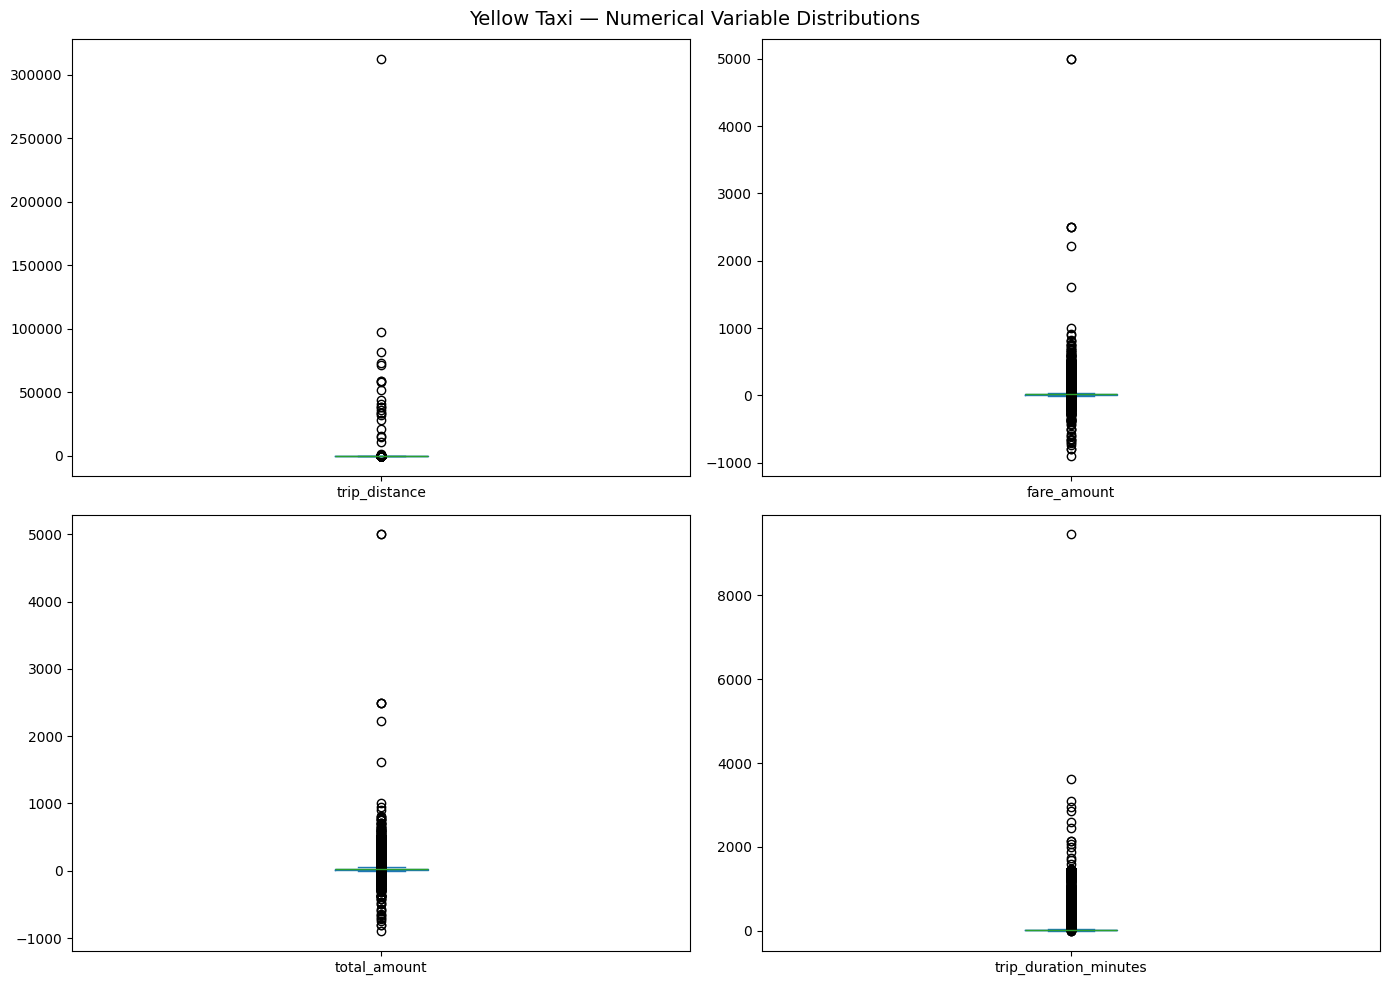

In [16]:
import matplotlib.pyplot as plt

yellow_sample[numeric_columns_yellow].plot(
    kind="box",
    subplots=True,
    figsize=(14, 10),
    layout=(2, 2),
    sharey=False
)

plt.suptitle("Yellow Taxi — Numerical Variable Distributions", fontsize=14)
plt.tight_layout()
plt.show()

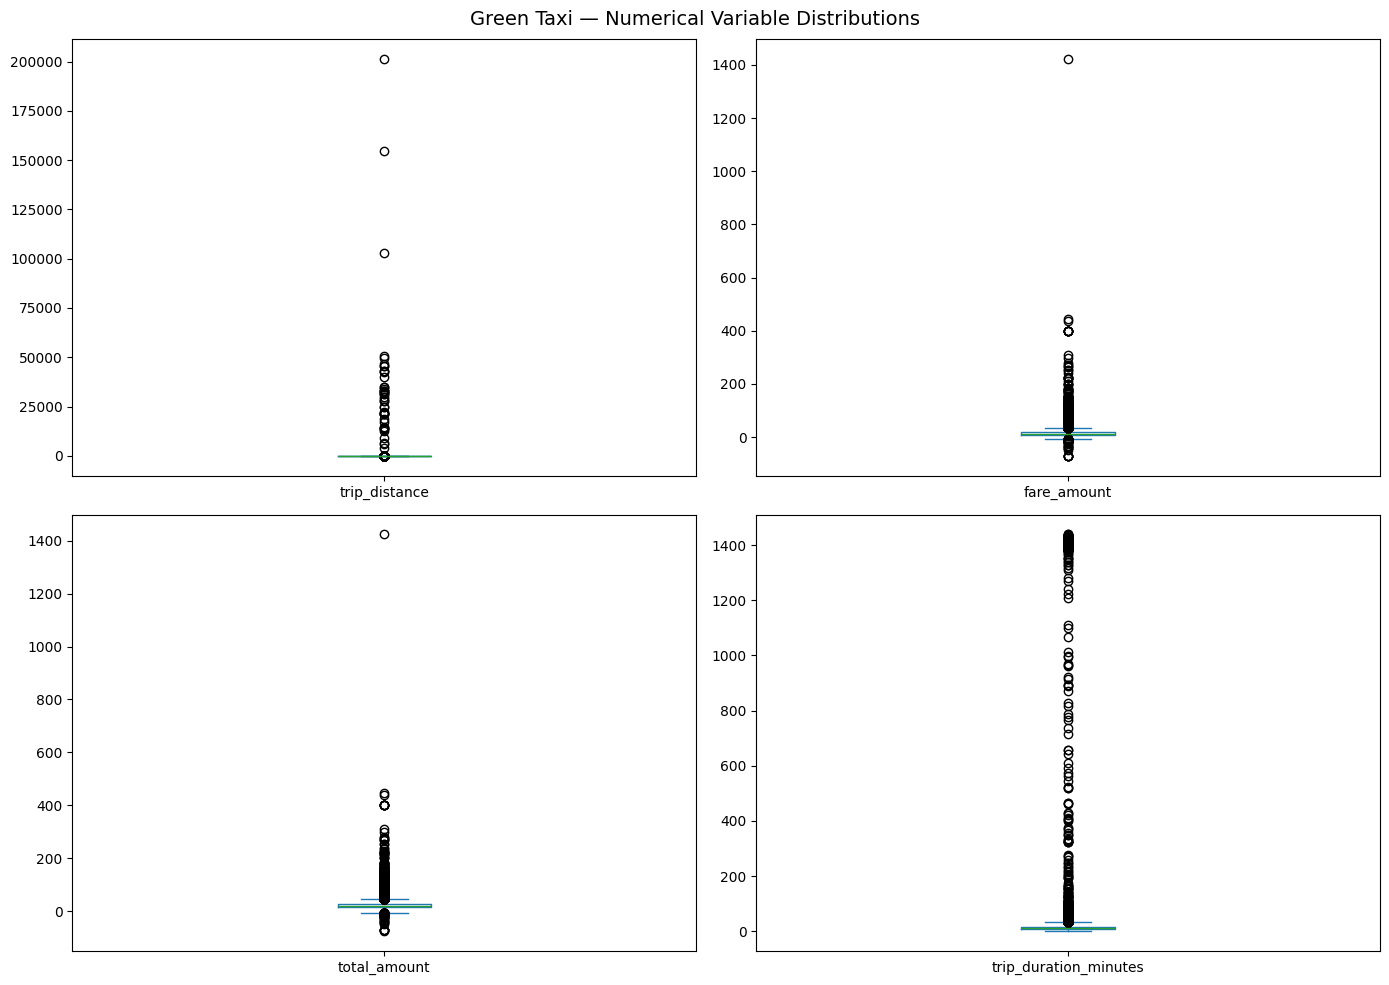

In [17]:
green_sample[numeric_columns_green].plot(
    kind="box",
    subplots=True,
    figsize=(14, 10),
    layout=(2, 2),
    sharey=False
)

plt.suptitle("Green Taxi — Numerical Variable Distributions", fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
def suspicious_value_summary(df, distance_col, fare_col, total_col, duration_col):
    return pd.DataFrame({
        "Metric": [
            "Zero distance",
            "Negative distance",
            "Negative fare",
            "Zero fare",
            "Negative total",
            "Zero total",
            "Negative duration",
            "Zero duration",
            "Duration > 3 hours",
            "Distance > 100",
            "Fare > 500",
            "Total > 500"
        ],
        "Count": [
            (df[distance_col] == 0).sum(),
            (df[distance_col] < 0).sum(),
            (df[fare_col] < 0).sum(),
            (df[fare_col] == 0).sum(),
            (df[total_col] < 0).sum(),
            (df[total_col] == 0).sum(),
            (df[duration_col] < 0).sum(),
            (df[duration_col] == 0).sum(),
            (df[duration_col] > 180).sum(),
            (df[distance_col] > 100).sum(),
            (df[fare_col] > 500).sum(),
            (df[total_col] > 500).sum()
        ]
    })


print("YELLOW TAXI")
display(
    suspicious_value_summary(
        yellow_sample,
        "trip_distance",
        "fare_amount",
        "total_amount",
        "trip_duration_minutes"
    )
)

print("\nGREEN TAXI")
display(
    suspicious_value_summary(
        green_sample,
        "trip_distance",
        "fare_amount",
        "total_amount",
        "trip_duration_minutes"
    )
)

YELLOW TAXI


,Metric,Count
0,Zero distance,60371
1,Negative distance,0
2,Negative fare,37448
3,Zero fare,893
4,Negative total,35504
5,Zero total,416
6,Negative duration,56
7,Zero duration,814
8,Duration > 3 hours,1983
9,Distance > 100,59



GREEN TAXI


,Metric,Count
0,Zero distance,2870
1,Negative distance,0
2,Negative fare,182
3,Zero fare,52
4,Negative total,185
5,Zero total,41
6,Negative duration,0
7,Zero duration,76
8,Duration > 3 hours,225
9,Distance > 100,46


In [19]:
def plot_main_distribution(df, column, title):
    upper_limit = df[column].quantile(0.99)

    plot_data = df[
        df[column].between(
            df[column].min(),
            upper_limit
        )
    ]

    plt.figure(figsize=(10, 5))
    plt.hist(plot_data[column], bins=50)

    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Number of Trips")

    plt.show()

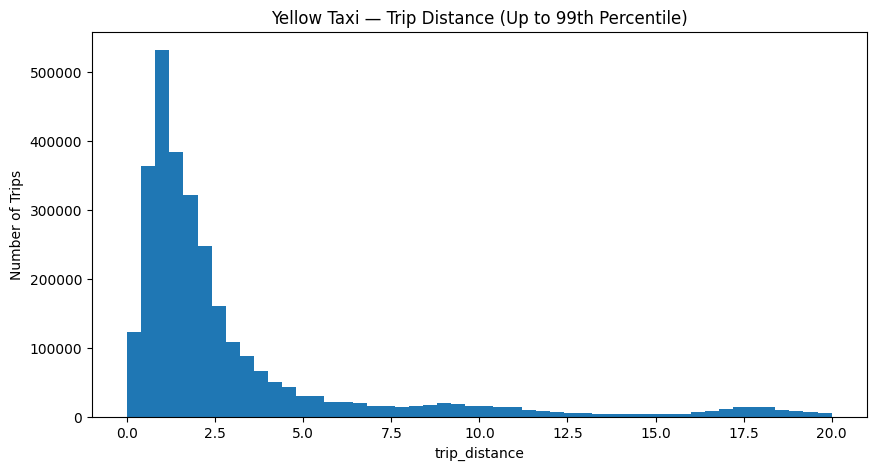

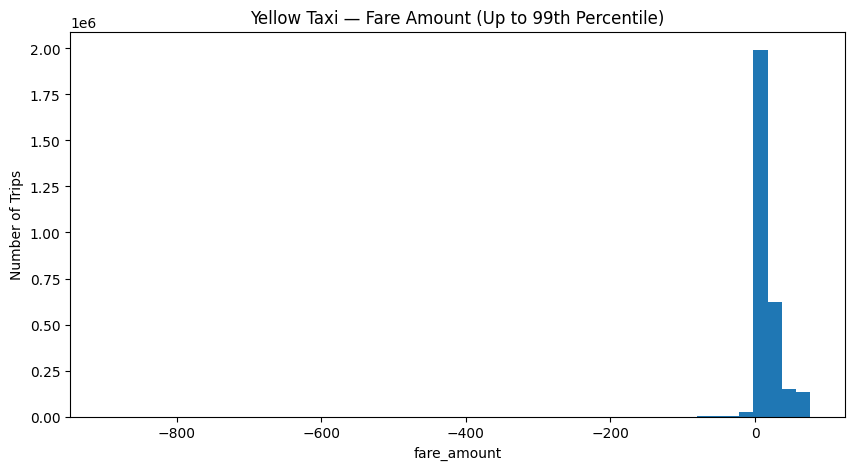

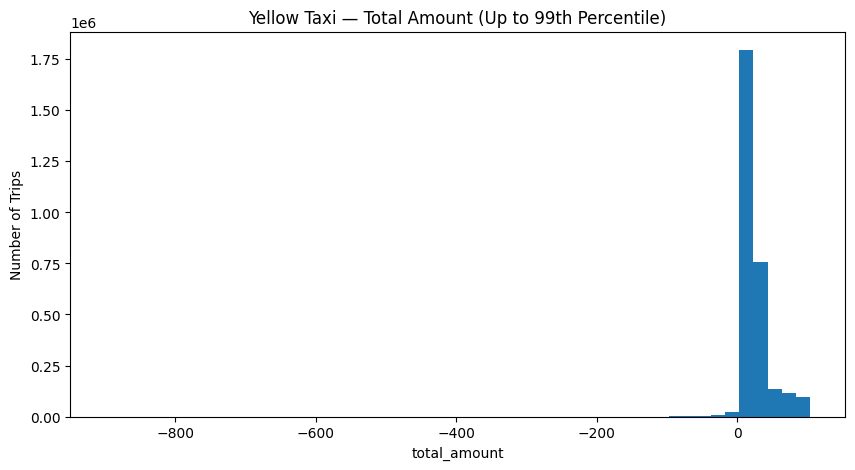

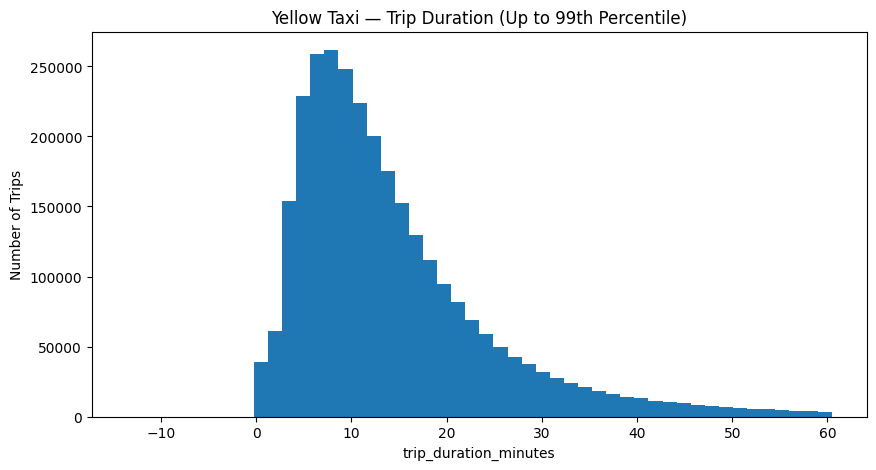

In [20]:
plot_main_distribution(
    yellow_sample,
    "trip_distance",
    "Yellow Taxi — Trip Distance (Up to 99th Percentile)"
)

plot_main_distribution(
    yellow_sample,
    "fare_amount",
    "Yellow Taxi — Fare Amount (Up to 99th Percentile)"
)

plot_main_distribution(
    yellow_sample,
    "total_amount",
    "Yellow Taxi — Total Amount (Up to 99th Percentile)"
)

plot_main_distribution(
    yellow_sample,
    "trip_duration_minutes",
    "Yellow Taxi — Trip Duration (Up to 99th Percentile)"
)

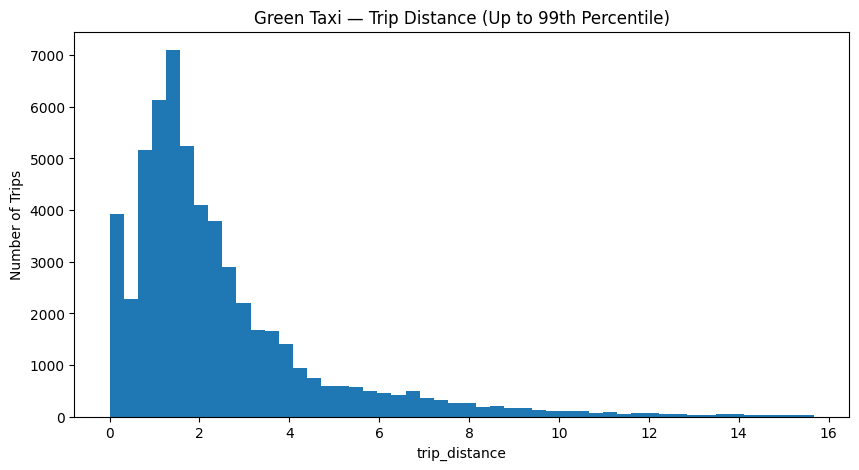

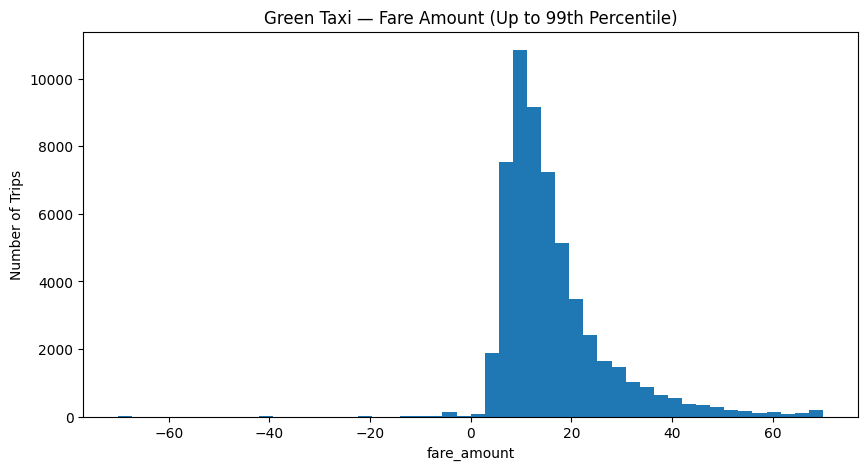

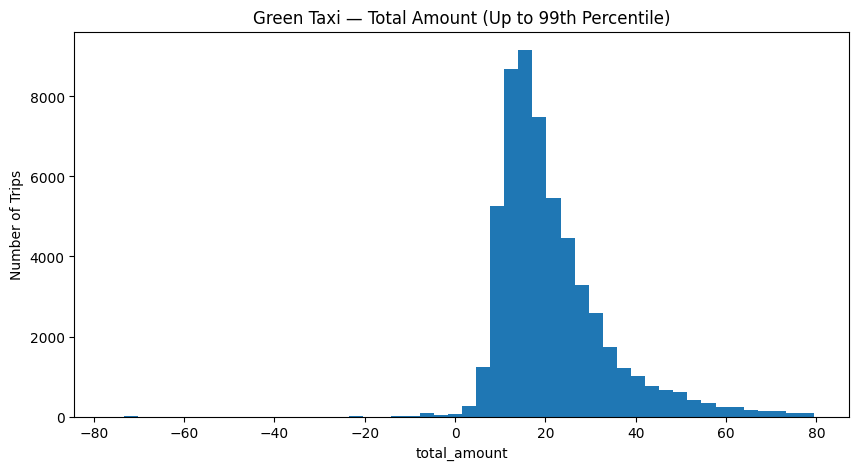

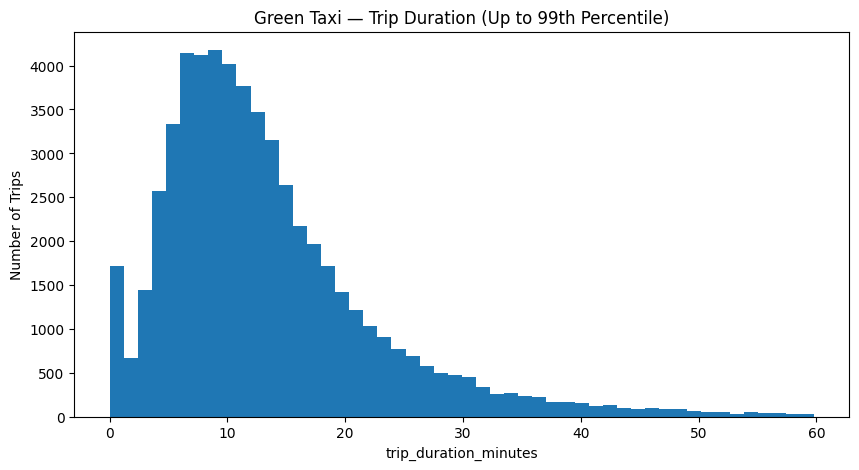

In [21]:
plot_main_distribution(
    green_sample,
    "trip_distance",
    "Green Taxi — Trip Distance (Up to 99th Percentile)"
)

plot_main_distribution(
    green_sample,
    "fare_amount",
    "Green Taxi — Fare Amount (Up to 99th Percentile)"
)

plot_main_distribution(
    green_sample,
    "total_amount",
    "Green Taxi — Total Amount (Up to 99th Percentile)"
)

plot_main_distribution(
    green_sample,
    "trip_duration_minutes",
    "Green Taxi — Trip Duration (Up to 99th Percentile)"
)

In [22]:
yellow_extreme_distance = (
    yellow_sample[
        yellow_sample["trip_distance"] > 100
    ][[
        "VendorID",
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "trip_distance",
        "fare_amount",
        "total_amount",
        "PULocationID",
        "DOLocationID",
        "payment_type"
    ]]
    .sort_values("trip_distance", ascending=False)
)

yellow_extreme_distance.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,total_amount,PULocationID,DOLocationID,payment_type
2958079,2,2024-01-30 06:37:00,2024-01-30 06:50:00,312722.30,14.46,22.15,151,162,0
2934895,2,2024-01-25 08:39:00,2024-01-25 09:06:00,97793.92,29.71,36.31,4,13,0
2911232,2,2024-01-20 08:01:00,2024-01-20 08:26:00,82015.45,16.56,21.56,40,43,0
2920143,2,2024-01-21 11:58:00,2024-01-21 12:12:00,72975.97,12.70,20.04,209,211,0
2891991,2,2024-01-17 08:41:00,2024-01-17 09:23:00,71752.26,41.06,49.57,33,161,0
2843369,2,2024-01-05 15:46:00,2024-01-05 16:17:00,59282.45,32.02,33.52,74,47,0
2854947,2,2024-01-09 07:13:00,2024-01-09 07:17:00,59076.43,13.82,23.17,141,162,0
2931119,2,2024-01-24 12:26:00,2024-01-24 12:42:00,58298.51,12.94,18.63,151,236,0
2868605,2,2024-01-12 05:16:00,2024-01-12 05:26:00,51619.36,16.17,24.20,238,186,0
2869099,2,2024-01-12 07:18:00,2024-01-12 07:38:00,44018.64,32.75,52.43,233,138,0


In [23]:
yellow_extreme_duration = (
    yellow_sample[
        yellow_sample["trip_duration_minutes"] > 180
    ][[
        "VendorID",
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "trip_duration_minutes",
        "trip_distance",
        "fare_amount",
        "total_amount",
        "PULocationID",
        "DOLocationID",
        "payment_type"
    ]]
    .sort_values("trip_duration_minutes", ascending=False)
)

yellow_extreme_duration.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount,total_amount,PULocationID,DOLocationID,payment_type
2111505,2,2024-01-24 17:03:14,2024-01-31 06:38:38,9455.400000,2.26,30.3,36.80,237,170,2
942462,2,2024-01-12 01:20:50,2024-01-14 13:42:36,3621.766667,35.70,150.4,181.41,132,42,2
1159593,2,2024-01-14 10:08:11,2024-01-16 13:54:22,3106.183333,31.95,2221.3,2225.30,220,220,2
2758973,2,2024-01-31 12:39:24,2024-02-02 13:56:52,2957.466667,0.00,3.0,4.50,207,260,2
1393159,2,2024-01-17 05:31:17,2024-01-19 05:12:10,2860.883333,0.20,28.9,33.90,162,162,2
2078351,2,2024-01-24 12:39:56,2024-01-26 07:45:44,2585.800000,0.00,3.0,4.50,207,226,2
2219253,2,2024-01-25 18:53:29,2024-01-27 11:32:13,2438.733333,4.56,21.9,28.40,140,133,2
837565,2,2024-01-10 23:28:44,2024-01-12 11:02:04,2133.333333,37.97,-70.0,-73.25,132,132,4
837566,2,2024-01-10 23:28:44,2024-01-12 11:02:04,2133.333333,37.97,70.0,73.25,132,132,4
1871822,2,2024-01-22 06:29:10,2024-01-23 17:07:01,2077.850000,20.35,70.0,75.75,132,100,2


In [24]:
yellow_negative_fares = (
    yellow_sample[
        yellow_sample["fare_amount"] < 0
    ][[
        "VendorID",
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "trip_duration_minutes",
        "trip_distance",
        "fare_amount",
        "total_amount",
        "payment_type",
        "PULocationID",
        "DOLocationID"
    ]]
    .sort_values("fare_amount")
)

yellow_negative_fares.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount,total_amount,payment_type,PULocationID,DOLocationID
1916204,2,2024-01-22 16:40:43,2024-01-22 19:11:20,150.616667,157.25,-899.0,-900.00,2,265,265
1518329,2,2024-01-18 11:26:33,2024-01-18 11:26:42,0.150000,0.00,-800.0,-801.00,3,33,33
1518327,2,2024-01-18 11:20:40,2024-01-18 11:20:56,0.266667,0.00,-800.0,-801.00,3,33,33
2354216,2,2024-01-26 23:59:09,2024-01-27 02:45:39,166.500000,120.76,-744.3,-753.74,4,143,265
1858567,2,2024-01-21 20:33:50,2024-01-21 20:33:56,0.100000,0.00,-709.0,-710.00,2,265,265
541145,2,2024-01-07 12:38:39,2024-01-07 12:38:59,0.333333,0.11,-700.0,-695.75,3,246,246
2095241,2,2024-01-24 15:21:37,2024-01-24 15:21:49,0.200000,0.00,-670.0,-671.00,3,66,66
1850351,2,2024-01-21 18:08:49,2024-01-21 20:15:48,126.983333,110.46,-669.4,-567.72,2,132,265
2610968,2,2024-01-29 19:19:21,2024-01-29 19:24:05,4.733333,2.46,-650.0,-652.75,4,132,219
2509695,2,2024-01-28 14:41:20,2024-01-28 16:37:25,116.083333,92.34,-607.8,-637.87,4,138,265


In [25]:
yellow_negative_fares.shape

(37448, 10)

In [26]:
yellow_negative_total = (
    yellow_sample[
        yellow_sample["total_amount"] < 0
    ][[
        "VendorID",
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "trip_duration_minutes",
        "trip_distance",
        "fare_amount",
        "total_amount",
        "payment_type",
        "PULocationID",
        "DOLocationID"
    ]]
    .sort_values("total_amount")
)

yellow_negative_total.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount,total_amount,payment_type,PULocationID,DOLocationID
1916204,2,2024-01-22 16:40:43,2024-01-22 19:11:20,150.616667,157.25,-899.0,-900.00,2,265,265
1518329,2,2024-01-18 11:26:33,2024-01-18 11:26:42,0.150000,0.00,-800.0,-801.00,3,33,33
1518327,2,2024-01-18 11:20:40,2024-01-18 11:20:56,0.266667,0.00,-800.0,-801.00,3,33,33
2354216,2,2024-01-26 23:59:09,2024-01-27 02:45:39,166.500000,120.76,-744.3,-753.74,4,143,265
1858567,2,2024-01-21 20:33:50,2024-01-21 20:33:56,0.100000,0.00,-709.0,-710.00,2,265,265
541145,2,2024-01-07 12:38:39,2024-01-07 12:38:59,0.333333,0.11,-700.0,-695.75,3,246,246
2095241,2,2024-01-24 15:21:37,2024-01-24 15:21:49,0.200000,0.00,-670.0,-671.00,3,66,66
2610968,2,2024-01-29 19:19:21,2024-01-29 19:24:05,4.733333,2.46,-650.0,-652.75,4,132,219
2509695,2,2024-01-28 14:41:20,2024-01-28 16:37:25,116.083333,92.34,-607.8,-637.87,4,138,265
569518,2,2024-01-07 19:19:53,2024-01-07 19:19:59,0.100000,0.00,-600.0,-591.00,3,265,265


In [27]:
yellow_financial_summary = pd.DataFrame({
    "Metric": [
        "Negative fare",
        "Negative total",
        "Negative fare AND negative total",
        "Negative fare with payment type 3",
        "Negative fare with payment type 4",
        "Negative fare with payment type 2",
        "Negative fare with payment type 0"
    ],
    "Count": [
        (yellow_sample["fare_amount"] < 0).sum(),
        (yellow_sample["total_amount"] < 0).sum(),
        (
            (yellow_sample["fare_amount"] < 0) &
            (yellow_sample["total_amount"] < 0)
        ).sum(),
        (
            (yellow_sample["fare_amount"] < 0) &
            (yellow_sample["payment_type"] == 3)
        ).sum(),
        (
            (yellow_sample["fare_amount"] < 0) &
            (yellow_sample["payment_type"] == 4)
        ).sum(),
        (
            (yellow_sample["fare_amount"] < 0) &
            (yellow_sample["payment_type"] == 2)
        ).sum(),
        (
            (yellow_sample["fare_amount"] < 0) &
            (yellow_sample["payment_type"] == 0)
        ).sum()
    ]
})

yellow_financial_summary

,Metric,Count
0,Negative fare,37448
1,Negative total,35504
2,Negative fare AND negative total,35384
3,Negative fare with payment type 3,5740
4,Negative fare with payment type 4,21406
5,Negative fare with payment type 2,8208
6,Negative fare with payment type 0,2066


In [28]:
yellow_zero_summary = pd.DataFrame({
    "Metric": [
        "Zero trip distance",
        "Zero fare",
        "Zero total",
        "Zero distance AND zero fare",
        "Zero distance AND zero total",
        "Zero fare AND zero total"
    ],
    "Count": [
        (yellow_sample["trip_distance"] == 0).sum(),
        (yellow_sample["fare_amount"] == 0).sum(),
        (yellow_sample["total_amount"] == 0).sum(),
        (
            (yellow_sample["trip_distance"] == 0) &
            (yellow_sample["fare_amount"] == 0)
        ).sum(),
        (
            (yellow_sample["trip_distance"] == 0) &
            (yellow_sample["total_amount"] == 0)
        ).sum(),
        (
            (yellow_sample["fare_amount"] == 0) &
            (yellow_sample["total_amount"] == 0)
        ).sum()
    ]
})

yellow_zero_summary

,Metric,Count
0,Zero trip distance,60371
1,Zero fare,893
2,Zero total,416
3,Zero distance AND zero fare,419
4,Zero distance AND zero total,287
5,Zero fare AND zero total,416


In [29]:
yellow_zero_distance = yellow_sample[
    yellow_sample["trip_distance"] == 0
][[
    "VendorID",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_duration_minutes",
    "trip_distance",
    "fare_amount",
    "total_amount",
    "payment_type",
    "PULocationID",
    "DOLocationID"
]]

yellow_zero_distance.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount,total_amount,payment_type,PULocationID,DOLocationID
17,2,2024-01-01 00:52:09,2024-01-01 00:52:28,0.316667,0.0,3.0,8.00,2,237,237
23,1,2024-01-01 00:14:29,2024-01-01 00:14:29,0.000000,0.0,3.0,8.00,2,236,264
111,1,2024-01-01 00:58:50,2024-01-01 01:01:10,2.333333,0.0,4.4,11.40,1,162,162
198,1,2024-01-01 00:15:16,2024-01-01 00:26:58,11.700000,0.0,10.7,18.80,1,79,264
199,1,2024-01-01 00:39:34,2024-01-01 01:04:02,24.466667,0.0,19.8,26.80,1,161,264
251,1,2024-01-01 00:18:26,2024-01-01 00:52:40,34.233333,0.0,52.5,60.94,1,222,147
580,2,2024-01-01 00:04:05,2024-01-01 00:04:11,0.100000,0.0,12.2,13.20,1,143,143
593,1,2024-01-01 00:25:58,2024-01-01 00:27:19,1.350000,0.0,10.0,13.20,1,114,114
600,1,2024-01-01 00:31:10,2024-01-01 00:36:41,5.516667,0.0,6.5,11.50,2,264,162
709,2,2024-01-01 00:28:27,2024-01-01 00:29:15,0.800000,0.0,180.0,217.20,1,265,265


In [30]:
yellow_zero_distance[
    [
        "trip_duration_minutes",
        "fare_amount",
        "total_amount",
        "payment_type"
    ]
].describe()

,trip_duration_minutes,fare_amount,total_amount,payment_type
count,60371.000000,60371.000000,60371.000000,60371.000000
mean,10.192377,23.712448,29.326312,1.103841
std,30.145658,48.185495,50.704028,1.173658
min,0.000000,-800.000000,-801.000000,0.000000
25%,0.216667,5.800000,11.105000,0.000000
50%,5.900000,15.350000,20.160000,1.000000
75%,15.283333,29.000000,33.820000,2.000000
max,2957.466667,5000.000000,5000.000000,4.000000


In [31]:
yellow_zero_distance_positive_fare = yellow_zero_distance[
    yellow_zero_distance["fare_amount"] > 0
]

yellow_zero_distance_positive_fare.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount,total_amount,payment_type,PULocationID,DOLocationID
17,2,2024-01-01 00:52:09,2024-01-01 00:52:28,0.316667,0.0,3.0,8.00,2,237,237
23,1,2024-01-01 00:14:29,2024-01-01 00:14:29,0.000000,0.0,3.0,8.00,2,236,264
111,1,2024-01-01 00:58:50,2024-01-01 01:01:10,2.333333,0.0,4.4,11.40,1,162,162
198,1,2024-01-01 00:15:16,2024-01-01 00:26:58,11.700000,0.0,10.7,18.80,1,79,264
199,1,2024-01-01 00:39:34,2024-01-01 01:04:02,24.466667,0.0,19.8,26.80,1,161,264
251,1,2024-01-01 00:18:26,2024-01-01 00:52:40,34.233333,0.0,52.5,60.94,1,222,147
580,2,2024-01-01 00:04:05,2024-01-01 00:04:11,0.100000,0.0,12.2,13.20,1,143,143
593,1,2024-01-01 00:25:58,2024-01-01 00:27:19,1.350000,0.0,10.0,13.20,1,114,114
600,1,2024-01-01 00:31:10,2024-01-01 00:36:41,5.516667,0.0,6.5,11.50,2,264,162
709,2,2024-01-01 00:28:27,2024-01-01 00:29:15,0.800000,0.0,180.0,217.20,1,265,265


In [32]:
yellow_zero_distance_nonpositive_fare = yellow_zero_distance[
    yellow_zero_distance["fare_amount"] <= 0
]

yellow_zero_distance_nonpositive_fare.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount,total_amount,payment_type,PULocationID,DOLocationID
1382,2,2024-01-01 00:33:28,2024-01-01 00:33:57,0.483333,0.0,-3.0,-8.0,4,162,162
2048,2,2024-01-01 00:08:26,2024-01-01 00:08:30,0.066667,0.0,-3.0,-5.5,3,234,234
2497,2,2024-01-01 00:45:08,2024-01-01 00:45:16,0.133333,0.0,-70.0,-74.0,4,237,237
3678,2,2024-01-01 00:27:18,2024-01-01 00:28:09,0.850000,0.0,-3.0,-8.0,2,163,163
4263,2,2024-01-01 00:29:27,2024-01-01 00:29:31,0.066667,0.0,-70.0,-74.0,3,163,163
4711,2,2024-01-01 00:28:47,2024-01-01 00:28:53,0.100000,0.0,-70.0,-74.0,4,114,114
6204,2,2024-01-01 01:56:19,2024-01-01 01:56:48,0.483333,0.0,-3.0,-8.0,4,107,107
6788,2,2024-01-01 01:55:30,2024-01-01 01:55:38,0.133333,0.0,-70.0,-71.5,2,152,152
6959,2,2024-01-01 01:33:41,2024-01-01 01:33:51,0.166667,0.0,-20.0,-21.0,4,168,168
7798,2,2024-01-01 01:58:27,2024-01-01 01:58:43,0.266667,0.0,-23.0,-26.5,4,48,48


In [33]:
yellow_negative_duration = yellow_sample[
    yellow_sample["trip_duration_minutes"] < 0
][[
    "VendorID",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_duration_minutes",
    "trip_distance",
    "fare_amount",
    "total_amount",
    "payment_type",
    "PULocationID",
    "DOLocationID"
]]

yellow_negative_duration.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount,total_amount,payment_type,PULocationID,DOLocationID
87994,1,2024-01-02 10:00:00,2024-01-02 09:53:56,-6.066667,7.20,38.50,46.94,1,75,95
253075,1,2024-01-04 12:30:00,2024-01-04 12:18:23,-11.616667,4.80,31.50,33.00,1,165,222
264032,1,2024-01-04 14:00:00,2024-01-04 13:55:50,-4.166667,5.60,27.50,29.00,1,95,80
349095,1,2024-01-05 11:00:00,2024-01-05 10:57:16,-2.733333,0.60,15.50,17.00,1,133,89
1436547,1,2024-01-17 14:25:00,2024-01-17 14:11:26,-13.566667,5.40,29.50,31.00,1,179,47
1520559,1,2024-01-18 11:00:00,2024-01-18 10:57:07,-2.883333,1.70,19.50,21.00,1,181,89
2280050,1,2024-01-26 11:30:00,2024-01-26 11:28:34,-1.433333,2.50,22.50,24.00,1,192,129
2385058,1,2024-01-27 11:00:00,2024-01-27 10:49:43,-10.283333,12.50,44.50,46.00,1,173,86
2827331,6,2024-01-01 02:01:50,2024-01-01 02:01:39,-0.183333,7.46,39.22,40.02,0,265,197
2828143,6,2024-01-01 03:01:46,2024-01-01 03:01:39,-0.116667,7.65,40.69,41.49,0,265,62


In [34]:
yellow_zero_duration = yellow_sample[
    yellow_sample["trip_duration_minutes"] == 0
][[
    "VendorID",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_duration_minutes",
    "trip_distance",
    "fare_amount",
    "total_amount",
    "payment_type",
    "PULocationID",
    "DOLocationID"
]]

yellow_zero_duration.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount,total_amount,payment_type,PULocationID,DOLocationID
23,1,2024-01-01 00:14:29,2024-01-01 00:14:29,0.0,0.0,3.00,8.00,2,236,264
16790,1,2024-01-01 02:47:57,2024-01-01 02:47:57,0.0,0.0,52.50,54.00,1,61,61
17277,1,2024-01-01 03:18:03,2024-01-01 03:18:03,0.0,0.0,33.99,33.99,2,246,264
19195,1,2024-01-01 03:06:02,2024-01-01 03:06:02,0.0,0.0,35.22,35.22,2,113,264
21393,1,2024-01-01 04:08:24,2024-01-01 04:08:24,0.0,0.0,10.70,15.70,2,249,264
22868,1,2024-01-01 04:06:44,2024-01-01 04:06:44,0.0,0.0,14.51,14.51,2,137,264
23585,1,2024-01-01 05:21:13,2024-01-01 05:21:13,0.0,0.0,0.00,1.00,2,48,264
25800,1,2024-01-01 07:33:54,2024-01-01 07:33:54,0.0,0.0,66.70,66.70,1,223,264
25801,1,2024-01-01 07:40:28,2024-01-01 07:40:28,0.0,0.0,46.00,46.00,1,223,264
28009,1,2024-01-01 09:24:09,2024-01-01 09:24:09,0.0,0.0,3.00,7.00,2,238,264


In [35]:
pd.DataFrame({
    "Metric": [
        "Negative duration",
        "Zero duration",
        "Positive duration"
    ],
    "Count": [
        (yellow_sample["trip_duration_minutes"] < 0).sum(),
        (yellow_sample["trip_duration_minutes"] == 0).sum(),
        (yellow_sample["trip_duration_minutes"] > 0).sum()
    ]
})

,Metric,Count
0,Negative duration,56
1,Zero duration,814
2,Positive duration,2963754


In [36]:
yellow_timestamp_summary = pd.DataFrame({
    "Metric": [
        "Minimum pickup datetime",
        "Maximum pickup datetime",
        "Minimum dropoff datetime",
        "Maximum dropoff datetime",
        "Pickup before 2024-01-01",
        "Pickup after 2024-01-31 23:59:59",
        "Dropoff before 2024-01-01",
        "Dropoff after 2024-01-31 23:59:59"
    ],
    "Value": [
        yellow_sample["tpep_pickup_datetime"].min(),
        yellow_sample["tpep_pickup_datetime"].max(),
        yellow_sample["tpep_dropoff_datetime"].min(),
        yellow_sample["tpep_dropoff_datetime"].max(),
        (yellow_sample["tpep_pickup_datetime"] < "2024-01-01").sum(),
        (yellow_sample["tpep_pickup_datetime"] > "2024-01-31 23:59:59").sum(),
        (yellow_sample["tpep_dropoff_datetime"] < "2024-01-01").sum(),
        (yellow_sample["tpep_dropoff_datetime"] > "2024-01-31 23:59:59").sum()
    ]
})

yellow_timestamp_summary

,Metric,Value
0,Minimum pickup datetime,2002-12-31 22:59:39
1,Maximum pickup datetime,2024-02-01 00:01:15
2,Minimum dropoff datetime,2002-12-31 23:05:41
3,Maximum dropoff datetime,2024-02-02 13:56:52
4,Pickup before 2024-01-01,15
5,Pickup after 2024-01-31 23:59:59,3
6,Dropoff before 2024-01-01,8
7,Dropoff after 2024-01-31 23:59:59,603


In [37]:
yellow_invalid_timestamps = yellow_sample[
    (yellow_sample["tpep_pickup_datetime"] < "2024-01-01") |
    (yellow_sample["tpep_pickup_datetime"] > "2024-01-31 23:59:59") |
    (yellow_sample["tpep_dropoff_datetime"] < "2024-01-01") |
    (yellow_sample["tpep_dropoff_datetime"] > "2024-01-31 23:59:59")
][[
    "VendorID",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_distance",
    "fare_amount",
    "total_amount",
    "payment_type",
    "PULocationID",
    "DOLocationID"
]]

yellow_invalid_timestamps.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,total_amount,payment_type,PULocationID,DOLocationID
256,2,2023-12-31 23:56:46,2024-01-01 00:12:06,2.38,15.6,21.60,1,236,142
369,2,2023-12-31 23:39:17,2023-12-31 23:42:00,0.47,5.1,10.10,1,90,68
753,2,2023-12-31 23:41:02,2023-12-31 23:48:03,0.40,7.2,12.20,2,246,246
2210,2,2023-12-31 23:57:17,2024-01-01 00:01:50,0.53,5.8,12.96,1,144,211
2615,2,2023-12-31 23:56:45,2024-01-01 00:00:28,0.97,6.5,13.50,1,163,237
2985,2,2023-12-31 23:49:12,2024-01-01 00:04:32,3.14,17.0,28.60,1,234,237
3176,2,2023-12-31 23:47:28,2023-12-31 23:57:07,1.44,10.7,18.84,1,68,137
4137,2,2023-12-31 23:58:35,2024-01-01 00:13:06,8.39,33.1,42.35,2,138,217
4142,2,2023-12-31 23:58:37,2024-01-01 00:08:37,0.59,10.0,18.75,1,161,170
8628,2,2023-12-31 23:54:27,2024-01-01 00:13:12,7.70,33.1,45.72,1,229,244


In [38]:
yellow_pickup_outside_month = yellow_sample[
    (yellow_sample["tpep_pickup_datetime"] < "2024-01-01") |
    (yellow_sample["tpep_pickup_datetime"] >= "2024-02-01")
][[
    "VendorID",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_duration_minutes",
    "trip_distance",
    "fare_amount",
    "total_amount",
    "payment_type",
    "PULocationID",
    "DOLocationID"
]].sort_values("tpep_pickup_datetime")

yellow_pickup_outside_month

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount,total_amount,payment_type,PULocationID,DOLocationID
53119,2,2002-12-31 22:59:39,2002-12-31 23:05:41,6.033333,0.63,-6.5,-10.50,3,170,170
53120,2,2002-12-31 22:59:39,2002-12-31 23:05:41,6.033333,0.63,6.5,10.50,3,170,170
2558056,2,2009-01-01 00:24:09,2009-01-01 01:13:00,48.850000,10.88,50.6,68.29,2,138,264
1230169,2,2009-01-01 23:30:39,2009-01-02 00:01:39,31.000000,10.99,45.0,50.00,2,237,264
10915,2,2009-01-01 23:58:40,2009-01-02 00:01:40,3.000000,0.46,4.4,9.40,2,137,264
369,2,2023-12-31 23:39:17,2023-12-31 23:42:00,2.716667,0.47,5.1,10.10,1,90,68
753,2,2023-12-31 23:41:02,2023-12-31 23:48:03,7.016667,0.40,7.2,12.20,2,246,246
3176,2,2023-12-31 23:47:28,2023-12-31 23:57:07,9.650000,1.44,10.7,18.84,1,68,137
2985,2,2023-12-31 23:49:12,2024-01-01 00:04:32,15.333333,3.14,17.0,28.60,1,234,237
8628,2,2023-12-31 23:54:27,2024-01-01 00:13:12,18.750000,7.70,33.1,45.72,1,229,244


In [39]:
yellow_sample.nsmallest(
    20,
    "tpep_pickup_datetime"
)[[
    "VendorID",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_duration_minutes",
    "trip_distance",
    "fare_amount",
    "total_amount",
    "payment_type",
    "PULocationID",
    "DOLocationID"
]]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount,total_amount,payment_type,PULocationID,DOLocationID
53119,2,2002-12-31 22:59:39,2002-12-31 23:05:41,6.033333,0.63,-6.5,-10.50,3,170,170
53120,2,2002-12-31 22:59:39,2002-12-31 23:05:41,6.033333,0.63,6.5,10.50,3,170,170
2558056,2,2009-01-01 00:24:09,2009-01-01 01:13:00,48.850000,10.88,50.6,68.29,2,138,264
1230169,2,2009-01-01 23:30:39,2009-01-02 00:01:39,31.000000,10.99,45.0,50.00,2,237,264
10915,2,2009-01-01 23:58:40,2009-01-02 00:01:40,3.000000,0.46,4.4,9.40,2,137,264
369,2,2023-12-31 23:39:17,2023-12-31 23:42:00,2.716667,0.47,5.1,10.10,1,90,68
753,2,2023-12-31 23:41:02,2023-12-31 23:48:03,7.016667,0.40,7.2,12.20,2,246,246
3176,2,2023-12-31 23:47:28,2023-12-31 23:57:07,9.650000,1.44,10.7,18.84,1,68,137
2985,2,2023-12-31 23:49:12,2024-01-01 00:04:32,15.333333,3.14,17.0,28.60,1,234,237
8628,2,2023-12-31 23:54:27,2024-01-01 00:13:12,18.750000,7.70,33.1,45.72,1,229,244


## Timestamp Validity Findings

Timestamp validation distinguishes between reporting-period boundaries and genuinely anomalous timestamps.

A monthly TLC file may contain trips that cross calendar-month boundaries. Therefore, a drop-off timestamp outside the file's month is not automatically invalid.

For analytical reporting, the pickup datetime will determine the trip's reporting month.

However, timestamps far outside the expected dataset period (for example, 2002 or 2009 timestamps in a 2024 file) are treated as anomalous. These records will be excluded from the analytical cleaned dataset while the original raw records remain preserved.

Additional timestamp validation includes:

- Drop-off before pickup → invalid trip duration
- Equal pickup and drop-off timestamps → retained
- Cross-month trips → retained when the pickup is valid
- Pickup records outside the intended reporting period → excluded from that month's analytical dataset

In [40]:
from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq

timestamp_quality_results = []

for file in parquet_files:
    # Read only timestamp columns to keep memory usage low
    schema = pq.ParquetFile(file).schema_arrow.names

    if "tpep_pickup_datetime" in schema:
        pickup_col = "tpep_pickup_datetime"
        dropoff_col = "tpep_dropoff_datetime"
    else:
        pickup_col = "lpep_pickup_datetime"
        dropoff_col = "lpep_dropoff_datetime"

    df_time = pd.read_parquet(
        file,
        columns=[pickup_col, dropoff_col]
    )

    df_time[pickup_col] = pd.to_datetime(df_time[pickup_col])
    df_time[dropoff_col] = pd.to_datetime(df_time[dropoff_col])

    duration = (
        df_time[dropoff_col] - df_time[pickup_col]
    ).dt.total_seconds() / 60

    # Determine expected reporting month from file name
    file_name = file.name

    # Example: yellow_tripdata_2024-01.parquet
    file_month = pd.Period(
        file_name.split("_")[-1].replace(".parquet", ""),
        freq="M"
    )

    expected_start = file_month.start_time
    expected_end = file_month.end_time

    timestamp_quality_results.append({
        "file": file_name,
        "taxi_type": file.parent.parent.name,
        "year": file_month.year,
        "month": file_month.month,
        "rows": len(df_time),

        "min_pickup": df_time[pickup_col].min(),
        "max_pickup": df_time[pickup_col].max(),

        "min_dropoff": df_time[dropoff_col].min(),
        "max_dropoff": df_time[dropoff_col].max(),

        "pickup_before_month": (
            df_time[pickup_col] < expected_start
        ).sum(),

        "pickup_after_month": (
            df_time[pickup_col] > expected_end
        ).sum(),

        "negative_duration": (
            duration < 0
        ).sum(),

        "zero_duration": (
            duration == 0
        ).sum(),

        "positive_duration": (
            duration > 0
        ).sum()
    })

timestamp_quality = pd.DataFrame(timestamp_quality_results)

timestamp_quality.head()

,file,taxi_type,year,month,rows,min_pickup,max_pickup,min_dropoff,max_dropoff,pickup_before_month,pickup_after_month,negative_duration,zero_duration,positive_duration
0,green_tripdata_2024-01.parquet,green,2024,1,56551,2023-12-31 14:38:47,2024-01-31 23:57:29,2023-12-31 14:46:45,2024-02-01 19:17:30,2,0,0,76,56475
1,green_tripdata_2024-02.parquet,green,2024,2,53577,2024-01-25 19:10:32,2024-02-29 23:56:40,2024-01-25 19:25:11,2024-03-01 19:56:23,6,0,0,48,53529
2,green_tripdata_2024-03.parquet,green,2024,3,57457,2008-12-31 23:02:24,2024-04-01 00:01:45,2008-12-31 23:02:30,2024-04-01 16:11:00,9,1,0,34,57423
3,green_tripdata_2024-04.parquet,green,2024,4,56471,2024-03-31 22:34:23,2024-04-30 23:59:33,2024-03-31 22:45:33,2024-05-01 23:35:25,4,0,0,70,56401
4,green_tripdata_2024-05.parquet,green,2024,5,61003,2009-01-01 00:27:54,2024-06-01 00:00:56,2009-01-01 00:32:44,2024-06-01 21:12:50,7,2,0,53,60950


In [41]:
timestamp_quality[
    (timestamp_quality["negative_duration"] > 0) |
    (timestamp_quality["pickup_before_month"] > 0) |
    (timestamp_quality["pickup_after_month"] > 0)
].sort_values(
    ["year", "month", "taxi_type"]
)

,file,taxi_type,year,month,rows,min_pickup,max_pickup,min_dropoff,max_dropoff,pickup_before_month,pickup_after_month,negative_duration,zero_duration,positive_duration
0,green_tripdata_2024-01.parquet,green,2024,1,56551,2023-12-31 14:38:47,2024-01-31 23:57:29,2023-12-31 14:46:45,2024-02-01 19:17:30,2,0,0,76,56475
31,yellow_tripdata_2024-01.parquet,yellow,2024,1,2964624,2002-12-31 22:59:39,2024-02-01 00:01:15,2002-12-31 23:05:41,2024-02-02 13:56:52,15,3,56,814,2963754
1,green_tripdata_2024-02.parquet,green,2024,2,53577,2024-01-25 19:10:32,2024-02-29 23:56:40,2024-01-25 19:25:11,2024-03-01 19:56:23,6,0,0,48,53529
32,yellow_tripdata_2024-02.parquet,yellow,2024,2,3007526,2008-12-31 22:52:49,2024-03-01 00:01:37,2008-12-31 23:04:09,2024-03-01 23:24:42,13,2,7,796,3006723
2,green_tripdata_2024-03.parquet,green,2024,3,57457,2008-12-31 23:02:24,2024-04-01 00:01:45,2008-12-31 23:02:30,2024-04-01 16:11:00,9,1,0,34,57423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,yellow_tripdata_2026-05.parquet,yellow,2026,5,4090836,2008-12-31 23:05:53,2026-06-01 00:20:35,2009-01-01 17:08:07,2026-06-02 12:53:42,13,1,0,52063,4038773
29,green_tripdata_2026-06.parquet,green,2026,6,44163,2026-05-26 19:47:06,2026-07-01 03:21:24,2026-05-26 19:55:33,2026-07-01 18:14:34,12,1,3,30,44130
60,yellow_tripdata_2026-06.parquet,yellow,2026,6,3837248,2008-12-31 23:03:25,2026-06-30 23:59:59,2009-01-01 14:28:05,2026-07-01 22:33:25,17,0,1,49806,3787441
30,green_tripdata_2026-07.parquet,green,2026,7,41252,2008-12-31 17:35:31,2026-08-01 14:36:42,2008-12-31 23:16:26,2026-08-01 14:49:11,11,5,0,23,41229


In [42]:
timestamp_quality[
    [
        "rows",
        "pickup_before_month",
        "pickup_after_month",
        "negative_duration",
        "zero_duration",
        "positive_duration"
    ]
].sum()

rows                   117806981
pickup_before_month          824
pickup_after_month           437
negative_duration           5168
zero_duration             885926
positive_duration      116915887
dtype: int64

In [43]:
import numpy as np

yellow_distance_analysis = yellow_sample.copy()

yellow_distance_analysis["avg_speed_mph"] = np.where(
    yellow_distance_analysis["trip_duration_minutes"] > 0,
    yellow_distance_analysis["trip_distance"]
    / (yellow_distance_analysis["trip_duration_minutes"] / 60),
    np.nan
)

yellow_distance_analysis[
    [
        "trip_distance",
        "trip_duration_minutes",
        "avg_speed_mph",
        "fare_amount",
        "total_amount"
    ]
].describe(
    percentiles=[0.50, 0.90, 0.95, 0.99, 0.999]
)

,trip_distance,trip_duration_minutes,avg_speed_mph,fare_amount,total_amount
count,2.964624e+06,2.964624e+06,2.963754e+06,2.964624e+06,2.964624e+06
mean,3.652169e+00,1.561295e+01,1.376820e+01,1.817506e+01,2.680150e+01
std,2.254626e+02,3.485105e+01,1.087234e+03,1.894955e+01,2.338558e+01
min,0.000000e+00,-1.356667e+01,0.000000e+00,-8.990000e+02,-9.000000e+02
50%,1.680000e+00,1.163333e+01,9.570997e+00,1.280000e+01,2.010000e+01
90%,8.420000e+00,2.886667e+01,2.001064e+01,3.857000e+01,5.340000e+01
95%,1.369000e+01,3.793333e+01,2.611404e+01,6.180000e+01,8.019000e+01
99%,2.000000e+01,6.045000e+01,3.700800e+01,7.580000e+01,1.033600e+02
99.9%,2.950377e+01,1.148710e+02,4.902224e+01,1.451000e+02,1.756775e+02
max,3.127223e+05,9.455400e+03,1.443334e+06,5.000000e+03,5.000000e+03


In [44]:
distance_checks = {
    "zero_distance": (yellow_distance_analysis["trip_distance"] == 0).sum(),
    "negative_distance": (yellow_distance_analysis["trip_distance"] < 0).sum(),
    "distance_over_50": (yellow_distance_analysis["trip_distance"] > 50).sum(),
    "distance_over_100": (yellow_distance_analysis["trip_distance"] > 100).sum(),
    "distance_over_500": (yellow_distance_analysis["trip_distance"] > 500).sum(),
    "speed_over_100": (yellow_distance_analysis["avg_speed_mph"] > 100).sum(),
    "speed_over_150": (yellow_distance_analysis["avg_speed_mph"] > 150).sum(),
    "speed_over_200": (yellow_distance_analysis["avg_speed_mph"] > 200).sum(),
}

distance_checks

{'zero_distance': np.int64(60371),
 'negative_distance': np.int64(0),
 'distance_over_50': np.int64(412),
 'distance_over_100': np.int64(59),
 'distance_over_500': np.int64(25),
 'speed_over_100': np.int64(1024),
 'speed_over_150': np.int64(909),
 'speed_over_200': np.int64(830)}

In [46]:
yellow_distance_analysis[
    [
        "VendorID",
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "trip_duration_minutes",
        "trip_distance",
        "avg_speed_mph",
        "fare_amount",
        "total_amount",
        "payment_type",
        "PULocationID",
        "DOLocationID"
    ]
].sort_values(
    "trip_distance",
    ascending=False
).head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,avg_speed_mph,fare_amount,total_amount,payment_type,PULocationID,DOLocationID
2958079,2,2024-01-30 06:37:00,2024-01-30 06:50:00,13.0,312722.30,1.443334e+06,14.46,22.15,0,151,162
2934895,2,2024-01-25 08:39:00,2024-01-25 09:06:00,27.0,97793.92,2.173198e+05,29.71,36.31,0,4,13
2911232,2,2024-01-20 08:01:00,2024-01-20 08:26:00,25.0,82015.45,1.968371e+05,16.56,21.56,0,40,43
2920143,2,2024-01-21 11:58:00,2024-01-21 12:12:00,14.0,72975.97,3.127542e+05,12.70,20.04,0,209,211
2891991,2,2024-01-17 08:41:00,2024-01-17 09:23:00,42.0,71752.26,1.025032e+05,41.06,49.57,0,33,161
2843369,2,2024-01-05 15:46:00,2024-01-05 16:17:00,31.0,59282.45,1.147402e+05,32.02,33.52,0,74,47
2854947,2,2024-01-09 07:13:00,2024-01-09 07:17:00,4.0,59076.43,8.861465e+05,13.82,23.17,0,141,162
2931119,2,2024-01-24 12:26:00,2024-01-24 12:42:00,16.0,58298.51,2.186194e+05,12.94,18.63,0,151,236
2868605,2,2024-01-12 05:16:00,2024-01-12 05:26:00,10.0,51619.36,3.097162e+05,16.17,24.20,0,238,186
2869099,2,2024-01-12 07:18:00,2024-01-12 07:38:00,20.0,44018.64,1.320559e+05,32.75,52.43,0,233,138


In [48]:
yellow_distance_analysis[
    [
        "VendorID",
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "trip_duration_minutes",
        "trip_distance",
        "avg_speed_mph",
        "fare_amount",
        "total_amount",
        "payment_type",
        "PULocationID",
        "DOLocationID"
    ]
].sort_values(
    "avg_speed_mph",
    ascending=False
).head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,avg_speed_mph,fare_amount,total_amount,payment_type,PULocationID,DOLocationID
2958079,2,2024-01-30 06:37:00,2024-01-30 06:50:00,13.0,312722.30,1.443334e+06,14.46,22.15,0,151,162
2854947,2,2024-01-09 07:13:00,2024-01-09 07:17:00,4.0,59076.43,8.861465e+05,13.82,23.17,0,141,162
2920143,2,2024-01-21 11:58:00,2024-01-21 12:12:00,14.0,72975.97,3.127542e+05,12.70,20.04,0,209,211
2868605,2,2024-01-12 05:16:00,2024-01-12 05:26:00,10.0,51619.36,3.097162e+05,16.17,24.20,0,238,186
2865355,2,2024-01-11 07:41:00,2024-01-11 07:48:00,7.0,33934.01,2.908629e+05,13.82,19.60,0,238,142
2931119,2,2024-01-24 12:26:00,2024-01-24 12:42:00,16.0,58298.51,2.186194e+05,12.94,18.63,0,151,236
2934895,2,2024-01-25 08:39:00,2024-01-25 09:06:00,27.0,97793.92,2.173198e+05,29.71,36.31,0,4,13
2911232,2,2024-01-20 08:01:00,2024-01-20 08:26:00,25.0,82015.45,1.968371e+05,16.56,21.56,0,40,43
2875656,2,2024-01-13 14:00:00,2024-01-13 14:13:00,13.0,41123.32,1.897999e+05,14.57,18.57,0,238,236
2875730,2,2024-01-13 15:50:00,2024-01-13 16:05:00,15.0,38131.83,1.525273e+05,19.39,29.24,0,66,113


In [49]:
yellow_distance_analysis[
    [
        "trip_distance",
        "trip_duration_minutes",
        "avg_speed_mph",
        "fare_amount",
        "total_amount"
    ]
].describe(
    percentiles=[0.50, 0.90, 0.95, 0.99, 0.999]
)

,trip_distance,trip_duration_minutes,avg_speed_mph,fare_amount,total_amount
count,2.964624e+06,2.964624e+06,2.963754e+06,2.964624e+06,2.964624e+06
mean,3.652169e+00,1.561295e+01,1.376820e+01,1.817506e+01,2.680150e+01
std,2.254626e+02,3.485105e+01,1.087234e+03,1.894955e+01,2.338558e+01
min,0.000000e+00,-1.356667e+01,0.000000e+00,-8.990000e+02,-9.000000e+02
50%,1.680000e+00,1.163333e+01,9.570997e+00,1.280000e+01,2.010000e+01
90%,8.420000e+00,2.886667e+01,2.001064e+01,3.857000e+01,5.340000e+01
95%,1.369000e+01,3.793333e+01,2.611404e+01,6.180000e+01,8.019000e+01
99%,2.000000e+01,6.045000e+01,3.700800e+01,7.580000e+01,1.033600e+02
99.9%,2.950377e+01,1.148710e+02,4.902224e+01,1.451000e+02,1.756775e+02
max,3.127223e+05,9.455400e+03,1.443334e+06,5.000000e+03,5.000000e+03


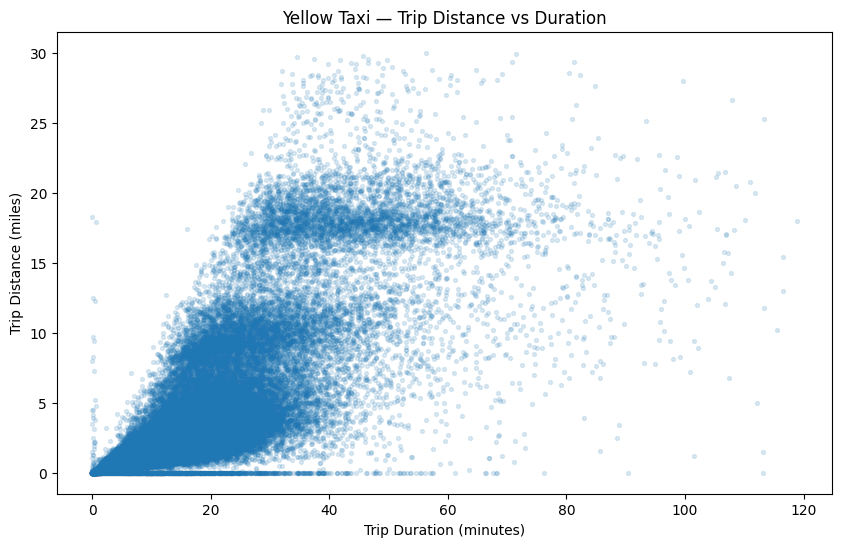

In [51]:
import matplotlib.pyplot as plt

plot_data = yellow_distance_analysis[
    (yellow_distance_analysis["trip_distance"] <= 30) &
    (yellow_distance_analysis["trip_duration_minutes"] > 0) &
    (yellow_distance_analysis["trip_duration_minutes"] <= 120)
].sample(
    min(100000, len(yellow_distance_analysis)),
    random_state=42
)

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data["trip_duration_minutes"],
    plot_data["trip_distance"],
    alpha=0.15,
    s=8
)

plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Trip Distance (miles)")
plt.title("Yellow Taxi — Trip Distance vs Duration")
plt.show()

In [52]:
yellow_distance_analysis.shape

(2964624, 21)

In [53]:
yellow_distance_analysis.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'trip_duration_minutes', 'avg_speed_mph'],
      dtype='object')

In [54]:
yellow_distance_analysis.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration_minutes,avg_speed_mph
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,...,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0,19.800000,5.212121
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,...,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,6.600000,16.363636
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,...,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0,17.916667,15.739535
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,...,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0,8.300000,10.120482
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,...,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0,6.100000,7.868852
